# 01 — Quickstart: a dose bundle in five minutes

> **OpenBNCT is research software.** Nothing computed here is a clinical, equivalence, commissioning, or regulatory claim. See `docs/DISCLAIMER.md`.
>
> Run from the repository root after `pip install openbnct` (the notebooks read committed artifacts by repository-relative paths).

This notebook loads the committed layered-head phantom dose bundle — a 28-group deterministic S_N solve — and exercises the read-only analysis surface: component inspection, a mid-plane dose map, a DVH, and exact dose-volume metrics.

## Load the bundle

`load_physical_dose_bundle` validates the artifact against its schema before returning it — a malformed bundle fails here, never downstream.

In [1]:
from pathlib import Path
import openbnct

# locate the repository root regardless of launch directory
REPO = Path.cwd()
while not (REPO / 'benchmarks').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / 'benchmarks').is_dir(), 'run inside an OpenBNCT checkout'

BENCH = REPO / 'benchmarks/synthetic/layered-head-phantom'
bundle = openbnct.load_physical_dose_bundle(BENCH / 'dose-28g-v2.json')
print(bundle.schema_version, bundle.case_id)
print('grid:', bundle.geometry.shape, 'voxels @',
      bundle.geometry.spacing_mm, 'mm')
print('provenance:', bundle.provenance_id)

openbnct.physical-dose-bundle/0.2.0 openbnct.layered-head-phantom.v1
grid: (25, 25, 25) voxels @ (8.0, 8.0, 8.0) mm
provenance: sn-s8-openbnct.layered-head-phantom.v1


## Components

Every bundle carries the four physical BNCT dose components separately — boron (¹⁰B(n,α)⁷Li), nitrogen (¹⁴N(n,p)¹⁴C), hydrogen (recoil protons), and photon — each with its own unit and an optional per-voxel standard uncertainty.

In [2]:
import math

rows = []
for c in bundle.components + [bundle.physical_total]:
    nz = sum(1 for v in c.values if v > 0)
    rows.append((c.component, c.unit, max(c.values), nz))
print(f'{"component":<14}{"unit":<30}{"max":>12}{"nonzero voxels":>16}')
for name, unit, mx, nz in rows:
    print(f'{name:<14}{unit:<30}{mx:>12.3e}{nz:>16}')

component     unit                                   max  nonzero voxels
boron         gray_per_source_particle         1.819e-16            3695
hydrogen      gray_per_source_particle         5.154e-14           15625
nitrogen      gray_per_source_particle         6.878e-15            8217
photon        gray_per_source_particle         5.479e-13           15625
physical_totalgray_per_source_particle         5.994e-13           15625


## Mid-plane dose map

The bundle stores voxel data x-fastest (`[column, row, slice]`, columns varying fastest), so NumPy's default C-order reshape takes the axes reversed — `(nz, ny, nx)` — and the central z-plane is `vol[nz // 2]`, a `(ny, nx)` image.

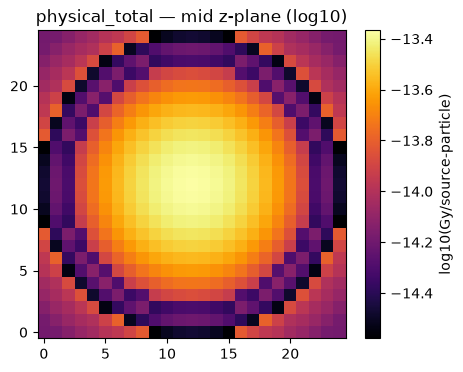

In [3]:
import matplotlib.pyplot as plt
import numpy as np

nx, ny, nz = bundle.geometry.shape
total = np.array(bundle.physical_total.values).reshape(nz, ny, nx)
mid = total[nz // 2]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(np.log10(mid + 1e-30), origin='lower', cmap='inferno')
ax.set_title('physical_total — mid z-plane (log10)')
fig.colorbar(im, ax=ax, label='log10(Gy/source-particle)')
plt.show()

## DVH and dose-volume metrics over the tumor mask

Masks are versioned `RegionMask` artifacts — name plus a boolean per grid voxel. `compute_metrics` is exact: D_x, V_x, and EUD are evaluated on the voxel values, not a histogram approximation.

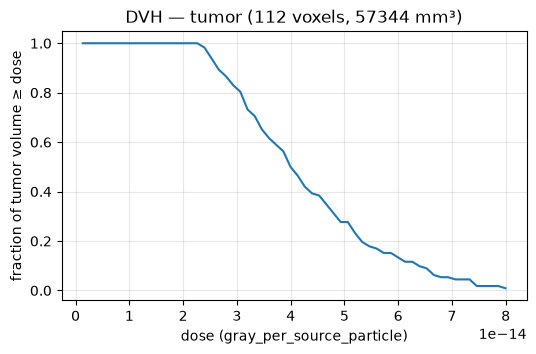

In [4]:
import json

mask = json.loads((BENCH / 'planning/tumor-mask.json').read_text())
dvh = openbnct.compute_dvh(bundle, 'physical_total',
                           mask['name'], mask['voxels'], bins=60)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(dvh.dose_edges[1:], dvh.cumulative_volume_fraction[1:])
ax.set_xlabel(f'dose ({dvh.unit})')
ax.set_ylabel('fraction of tumor volume ≥ dose')
ax.set_title(f'DVH — {dvh.region} '
             f'({dvh.region_voxel_count} voxels, '
             f'{dvh.region_volume_mm3:.0f} mm³)')
ax.grid(alpha=0.3)
plt.show()

In [5]:
met = openbnct.compute_metrics(bundle, 'physical_total',
                               mask['name'], mask['voxels'],
                               dx=[2.0, 50.0, 98.0],
                               # V_x thresholds are absolute doses —
                               # this bundle is Gy/source-particle,
                               # so pick in-range values
                               vx=[4.0e-14, 6.0e-14], eud=[-10.0])
print(f"mean  {met.mean_dose:.3e}  min {met.minimum_dose:.3e}  "
      f"max {met.maximum_dose:.3e} {met.unit}")
print('D_x:', {x: f'{v:.3e}' for x, v in met.dx})
print('V_x:', {x: f'{v:.3f}' for x, v in met.vx})
print('EUD:', {a: f'{v:.3e}' for a, v in met.eud})

mean  4.272e-14  min 2.298e-14  max 7.995e-14 gray_per_source_particle
D_x: {2.0: '7.433e-14', 50.0: '3.999e-14', 98.0: '2.417e-14'}
V_x: {4e-14: '0.500', 6e-14: '0.134'}
EUD: {-10.0: '3.001e-14'}


**Next:** `02-biological-modeling.ipynb` applies the biological layer; `03-uncertainty.ipynb` walks the evaluated-covariance chain.